In [2]:
import math
import random

import fresnel
import freud
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import PIL
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use("../../figures.mplstyle")

In [3]:
def replica(chr_number):

    beads = 121504
    sigma = 1
    density = 0.1
    dist = [1.0, 2.0]

    R_nucleus = (beads * (sigma / 2.0) ** 3 / density) ** (1.0 / 3)

    def fibonacci_sphere(samples=1, randomize=True):
        rnd = 1.0
        if randomize:
            rnd = random.random() * samples

        points = []
        offset = 2.0 / samples
        increment = math.pi * (3.0 - math.sqrt(5.0))

        for i in range(samples):
            y = ((i * offset) - 1) + (offset / 2)
            r = math.sqrt(1 - pow(y, 2))

            phi = ((i + rnd) % samples) * increment

            x = math.cos(phi) * r
            z = math.sin(phi) * r

            points.append([x, y, z])

        return points

    points = fibonacci_sphere(samples=chr_number)

    np.random.shuffle(points)

    for i in range(chr_number):
        points[i] = [x * dist[0] * R_nucleus for x in points[i]]

    L = 2 * R_nucleus
    box = freud.box.Box.cube(L)
    voro = freud.locality.Voronoi()

    cells = voro.compute((box, points)).polytopes

    nlist = voro.nlist

    contacts = np.zeros((chr_number, chr_number))

    for i, j in nlist[:]:
        if contacts[i][j] == 0:
            contacts[i][j] += 1

    return contacts


def fibonacci(chr_number):

    beads = 121504
    sigma = 1
    density = 0.1
    dist = [1.0, 2.0]

    R_nucleus = (beads * (sigma / 2.0) ** 3 / density) ** (1.0 / 3)

    def fibonacci_sphere(samples=1, randomize=True):
        rnd = 1.0
        if randomize:
            rnd = random.random() * samples

        points = []
        offset = 2.0 / samples
        increment = math.pi * (3.0 - math.sqrt(5.0))

        for i in range(samples):
            y = ((i * offset) - 1) + (offset / 2)
            r = math.sqrt(1 - pow(y, 2))

            phi = ((i + rnd) % samples) * increment

            x = math.cos(phi) * r
            z = math.sin(phi) * r

            points.append([x, y, z])

        return points

    points = fibonacci_sphere(samples=chr_number)

    np.random.shuffle(points)

    for i in range(chr_number):
        points[i] = [x * dist[0] * R_nucleus for x in points[i]]

    return points

In [4]:
def total_contacts(num_replicas):
    chr_number = 46

    contacts = np.zeros((chr_number, chr_number))

    for _ in range(num_replicas):
        contacts += replica(chr_number)

    return contacts

In [5]:
def create_continuous_cmap():
    # Define the colors for the colormap (blue, black, red)
    colors = [
        "#570000",
        "#CA7320",
        "#ECFFA5",
        "#369698",
        "#002C2D",
    ]  # RGB values

    # Create a list of positions for each color
    positions = [0.0, 0.25, 0.5, 0.75, 1.0]

    # Create the colormap using LinearSegmentedColormap
    custom_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "chromosomes", list(zip(positions, colors)), N=23
    )

    return custom_cmap


cmap = create_continuous_cmap()

In [6]:
colors = cmap([x if x < 23 else x - 23 for x in range(46)])

In [7]:
def plot_with_fresnel(
    positions,
    colors=None,
):
    device = fresnel.Device()
    scene = fresnel.Scene(device)
    scene.lights = fresnel.light.cloudy()

    geometry = fresnel.geometry.Sphere(
        scene,
        position=positions,
        radius=5,
        color=fresnel.color.linear(colors),
    )

    geometry.material = fresnel.material.Material(
        roughness=0.8,
        specular=1.0,
        primitive_color_mix=1,
        solid=0.0,
    )

    scene.camera = fresnel.camera.Orthographic.fit(scene)

    # increasing resolution or number of samples will significantly increase the time it takes to render
    out = fresnel.pathtrace(
        scene, samples=16, light_samples=16, w=1000, h=1000
    )
    PIL.Image.fromarray(out[:], mode="RGBA").save("sphere.png")

In [8]:
positions = fibonacci(46)

In [9]:
plot_with_fresnel(positions, colors)

In [10]:
beads = 121504
sigma = 1
density = 0.1
dist = [1.0, 2.0]

R_nucleus = (beads * (sigma / 2.0) ** 3 / density) ** (1.0 / 3)

In [11]:
box = freud.box.Box.cube(2 * R_nucleus)

voro = freud.locality.Voronoi()
cells = voro.compute((box, positions)).polytopes

In [12]:
def plot_voronoi_with_fresnel(
    vertices,
    colors=None,
):
    device = fresnel.Device()
    scene = fresnel.Scene(device)
    scene.lights = fresnel.light.cloudy()

    geometry = {}
    for i, cell in enumerate(vertices):
        poly_info = fresnel.util.convex_polyhedron_from_vertices(cell)

        geometry[i] = fresnel.geometry.ConvexPolyhedron(
            scene,
            poly_info,
            color=fresnel.color.linear(colors[i]),
        )

        geometry[i].material = fresnel.material.Material(
            roughness=0.8,
            specular=1.0,
            primitive_color_mix=1,
            solid=0.0,
        )

    scene.camera = fresnel.camera.Orthographic.fit(scene)
    
    # increasing resolution or number of samples will significantly increase the time it takes to render
    out = fresnel.pathtrace(
        scene, samples=16, light_samples=16, w=1000, h=1000
    )
    PIL.Image.fromarray(out[:], mode="RGBA").save(
        "voronoi.png"
    )

In [13]:
plot_voronoi_with_fresnel(cells, colors)

In [14]:
nlist = voro.nlist

contacts = np.zeros((46, 46))

for i, j in nlist[:]:
    if contacts[i][j] == 0:
        contacts[i][j] += 1

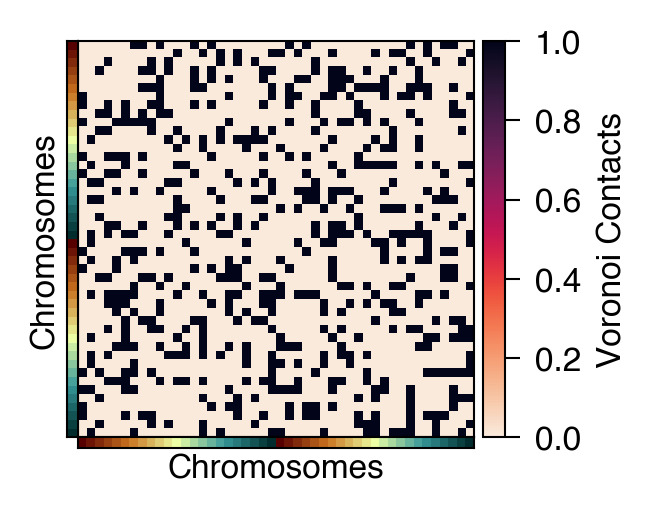

In [15]:
fig, ax = plt.subplots(
    1, 1, figsize=(2.3, 1.76)
)

ctt_cmap = sns.color_palette("rocket_r", as_cmap=True)

im = ax.imshow(contacts, cmap=ctt_cmap)

ax.set_xlabel("Chromosomes")
ax.set_ylabel("Chromosomes")

ax.set_xticks(ticks=[])
ax.set_yticks(ticks=[])

divider = make_axes_locatable(ax)

ax_right = divider.append_axes("right", size=0.075, pad=0.03)
fig.colorbar(im, cax=ax_right, label="Voronoi Contacts")

ax_left = divider.append_axes("left", size=f"2.6%", pad=0.0)
for i, color in enumerate(colors):
    rect = mpl.patches.Rectangle(
        (0, -0.5 + i), 1, 1, facecolor=color, linewidth=0
    )
    ax_left.add_patch(rect)
ax_left.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    top=False,
    labelbottom=False,
    labeltop=False,
    labelleft=False,
    labelright=False,
)
ax_left.set_ylim(len(colors) - 0.5, -0.5)
ax_left.set_xlim(0, 1)


ax_bottom = divider.append_axes("bottom", size="2.6%", pad=0.0)
for i, color in enumerate(colors):
    rect = mpl.patches.Rectangle(
        (-0.5 + i, 0), 1, 1, facecolor=color, linewidth=0
    )
    ax_bottom.add_patch(rect)
ax_bottom.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    top=False,
    labelbottom=False,
    labeltop=False,
    labelleft=False,
    labelright=False,
)
ax_bottom.set_xlim(-0.5, len(colors) - 0.5)

fig.tight_layout()

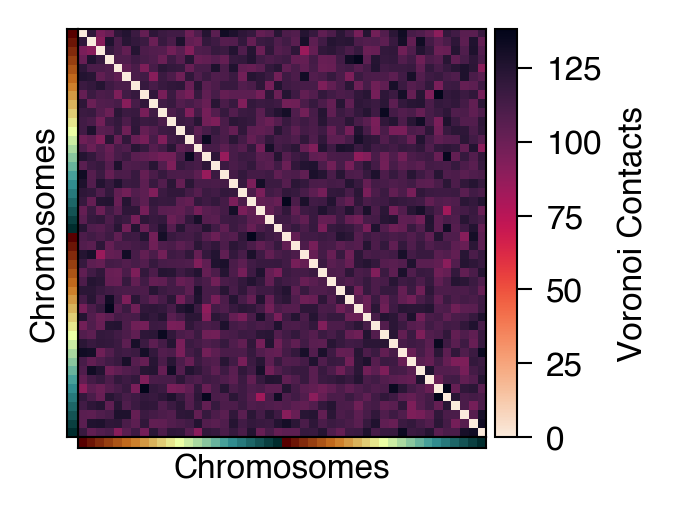

In [16]:
fig, ax = plt.subplots(
    1, 1, figsize=(2.3, 1.76)
)

ctt_cmap = sns.color_palette("rocket_r", as_cmap=True)

contact_matrix = total_contacts(400)

im = ax.imshow(contact_matrix, cmap=ctt_cmap)

ax.set_xlabel("Chromosomes")
ax.set_ylabel("Chromosomes")

ax.set_xticks(ticks=[])
ax.set_yticks(ticks=[])

divider = make_axes_locatable(ax)

ax_right = divider.append_axes("right", size=0.075, pad=0.03)
fig.colorbar(im, cax=ax_right, label="Voronoi Contacts")

ax_left = divider.append_axes("left", size=f"2.6%", pad=0.0)
for i, color in enumerate(colors):
    rect = mpl.patches.Rectangle(
        (0, -0.5 + i), 1, 1, facecolor=color, linewidth=0
    )
    ax_left.add_patch(rect)
ax_left.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    top=False,
    labelbottom=False,
    labeltop=False,
    labelleft=False,
    labelright=False,
)
ax_left.set_ylim(len(colors) - 0.5, -0.5)
ax_left.set_xlim(0, 1)


ax_bottom = divider.append_axes("bottom", size="2.6%", pad=0.0)
for i, color in enumerate(colors):
    rect = mpl.patches.Rectangle(
        (-0.5 + i, 0), 1, 1, facecolor=color, linewidth=0
    )
    ax_bottom.add_patch(rect)
ax_bottom.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    top=False,
    labelbottom=False,
    labeltop=False,
    labelleft=False,
    labelright=False,
)
ax_bottom.set_xlim(-0.5, len(colors) - 0.5)

fig.tight_layout()

In [17]:
CV = []
num_replicas = []

for i in range(1, 601, 10):
    Contacts = total_contacts(i)
    CV.append(np.std(Contacts) / np.mean(Contacts))
    num_replicas.append(i)

In [18]:
Contacts = total_contacts(600)
CV.append(np.std(Contacts) / np.mean(Contacts))
num_replicas.append(600)

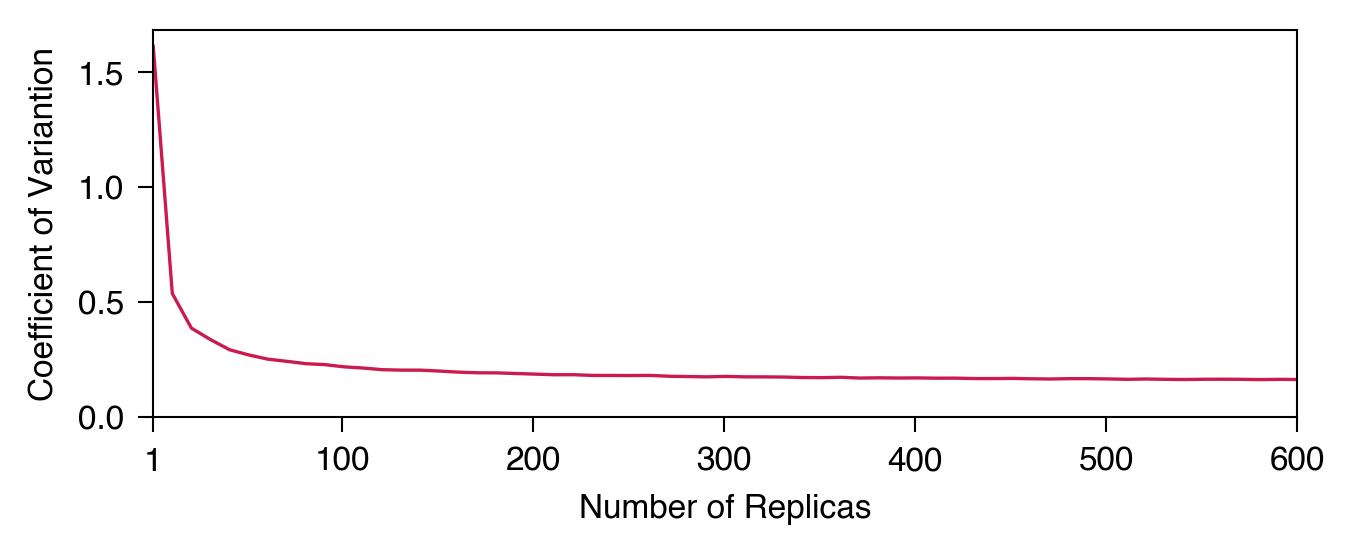

In [19]:
fig, ax = plt.subplots(
    1, 1, figsize=(4.4, 1.735), layout="constrained"
)

ctt_cmap = sns.color_palette("rocket_r", as_cmap=True)

ax.plot(num_replicas, CV, color=ctt_cmap(0.5))

ax.set_xlabel("Number of Replicas")
ax.set_ylabel("Coefficient of Variantion")

ax.set_xlim(1, 600)
ax.set_ylim(bottom=0)

ax.set_xticks([1, 100, 200, 300, 400, 500, 600])